In [175]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import h5py
import pickle 
import numpy as np 

from helpers import * 
from kerasAC.helpers.format_interpretations import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
chrom="chr1"
cell_line="K562"
fold="0"

In [28]:
vierstra=get_motif_offsets_for_peaks("/srv/scratch/annashch/chrombpnet/accuracy_footprint_compare/vierstra_idr_intersections/"+cell_line+".vierstra.idr.intersections.bed",'chr1')

In [29]:
list(vierstra.keys())[0:10]

[('chr1', 629171),
 ('chr1', 629359),
 ('chr1', 629729),
 ('chr1', 629555),
 ('chr1', 630274),
 ('chr1', 630403),
 ('chr1', 630886),
 ('chr1', 634300),
 ('chr1', 634177),
 ('chr1', 634042)]

In [5]:
len(vierstra)

15252

In [6]:
cur_shap=pickle.load(open("/srv/scratch/annashch/chrombpnet/k562_dnase/bpnet/interpret/K562.DNASE.bias_corrected_bpnet_tobias.fold0.deepSHAP",'rb'))


In [7]:
cur_shap.keys()

dict_keys(['label_prof', 'label_sum', 'pred_prof', 'pred_sum', 'profile_shap', 'count_shap', 'seq'])

In [8]:
class_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/classification/K562/interpretation/DNASE.K562.0.deepSHAP.interp.npz",
                                  "chr1")    


In [9]:
reg_shap=format_binary_deepshap("/srv/scratch/annashch/bias_correction/uncorrected/regression/K562/interpretation/DNASE.K562.0.deepSHAP.interp.npz",
                               "chr1")


In [10]:
gkm_scores=format_gkm_scores("/oak/stanford/groups/akundaje/projects/enzymatic_bias_correction/svm/aggregate/gkmexplain.K562.0.txt",
                            "chr1")


In [176]:
coord=list(gkm_scores.keys())[0]

In [177]:
coord

('chr1', 28927947)

In [178]:
#get the bpnet profile & count shap values 

label_prob, label_sum, pred_prob, pred_sum, profile_shap, count_shap, seq, minval_perf, maxval_perf, minval_shap, maxval_shap=extract_region(coord,cur_shap)
profile_shap.shape

(1000, 4)

In [179]:
#classification shap 
binary_class_shap=class_shap[coord]
binary_class_shap.shape

(1000, 4)

In [180]:
#regression shap 
binary_reg_shap=reg_shap[coord]
binary_reg_shap.shape

(1000, 4)

In [181]:
#gkm explain score 
gkm_score=gkm_scores[coord]
gkm_score.shape

(1000, 4)

In [182]:
motif_coords=vierstra[coord]


In [183]:
#get min/max shap scores 
minval=min([profile_shap.min(),count_shap.min(),binary_class_shap.min(),binary_reg_shap.min(),gkm_score.min()])
maxval=max([profile_shap.max(),count_shap.max(),binary_class_shap.max(),binary_reg_shap.max(),gkm_score.max()])

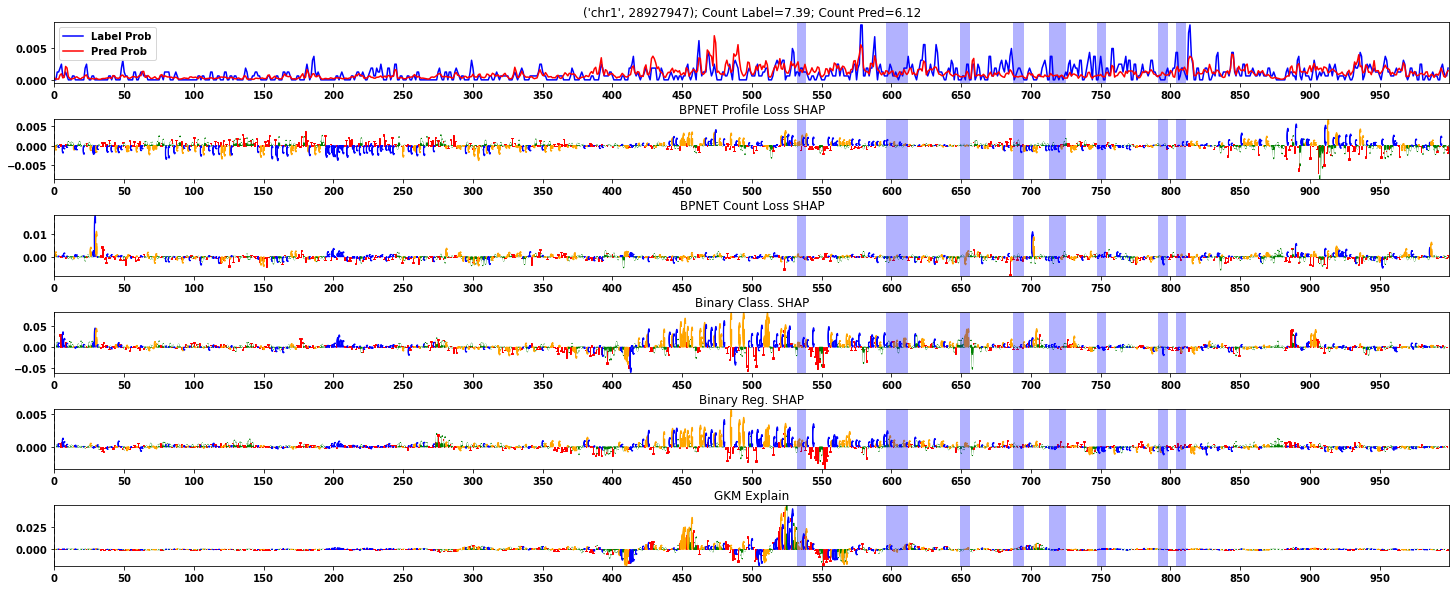

In [184]:
make_plot(coord,
          label_prob,
          pred_prob,
          profile_shap,
          count_shap,
          label_sum,
          pred_sum,
          seq,
          binary_class_shap,
          binary_reg_shap,
          gkm_score,
          xmin=0,
          xmax=1000,
          motif_coords=motif_coords)

In [185]:
coord[1]-500

28927447

In [186]:
coord[1]+500

28928447